<a href="https://colab.research.google.com/github/nasif-raihan/GSU/blob/main/CSCI_7090_Module1_Homework.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Module 1 — Homework
**Computer Vision**

Work through this single problem set. It uses one openly available image (from `skimage.data`) chosen for you from your **roll number**, so your specific numbers — pixel, ROI, brightness step, and target channel — are unique to you. Answers copied from someone else (or from a chatbot that has not run *your* seed) will not match your outputs.

## Rules
- Set `ROLL_NUMBER` in the first cell, then **Run all**.
- Fill in every `# TODO`. Do **not** edit the seeding / parameter lines.
- For every **Written** prompt, answer in your own words and refer to **your** numbers.
- Run the final **Submission Summary** cell and keep its output in your file.
- Submit this `.ipynb` with all cells executed (outputs visible).

## Grading (100 pts — scale to course policy)
Q1 Load & inspect **10** · Q2 Pixel probing **15** · Q3 Safe brightness **20** · Q4 ROI & channel edit **20** · Q5 Annotation **20** · Q6 Debug & reflect **15**

_Estimated time: 1–2 hours._

Roll: 901503252 | seed: 279384723
Image: astronaut | shape: (512, 512, 3) | dtype: uint8
PIXEL (x,y)=(440,118) | DELTA=82 | ROI=(37,103)->(410,381) | ZERO_CH=0


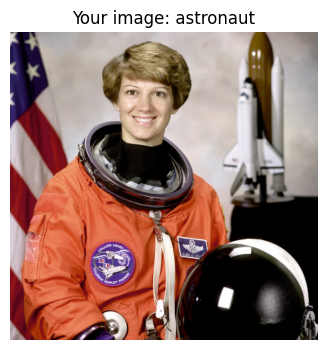

In [ ]:
# === SETUP — run first ===
ROLL_NUMBER = "901503252"
import hashlib
import numpy as np
import cv2
import matplotlib.pyplot as plt
from skimage import data

# Stable per-student seed from the roll number
seed = int(hashlib.sha256(ROLL_NUMBER.encode()).hexdigest(), 16) % (2**32)
rng  = np.random.default_rng(seed)

# Your image (skimage returns RGB; we convert to OpenCV BGR)
POOL = {"astronaut": data.astronaut, "coffee": data.coffee,
        "chelsea": data.chelsea, "rocket": data.rocket}
img_name = list(POOL)[int(rng.integers(0, len(POOL)))]
img = cv2.cvtColor(POOL[img_name](), cv2.COLOR_RGB2BGR)
H, W = img.shape[:2]

# Your personal parameters (unique to your roll number) — DO NOT EDIT
PX, PY   = int(rng.integers(0, W)), int(rng.integers(0, H))                    # a pixel (x, y)
DELTA    = int(rng.integers(40, 120))                                          # brightness step
RX1, RY1 = int(rng.uniform(0.05, 0.35)*W), int(rng.uniform(0.05, 0.35)*H)      # ROI top-left
RX2, RY2 = int(rng.uniform(0.55, 0.90)*W), int(rng.uniform(0.55, 0.90)*H)      # ROI bottom-right
ZERO_CH  = int(rng.integers(0, 3))                                             # channel to zero (0=B,1=G,2=R)

def show(bgr, title=""):
    plt.figure(figsize=(4,4))
    if bgr.ndim == 2:
        plt.imshow(bgr, cmap="gray", vmin=0, vmax=255)
    else:
        plt.imshow(cv2.cvtColor(bgr, cv2.COLOR_BGR2RGB))

    plt.title(title)
    plt.axis("off")
    plt.show()

print("Roll:", ROLL_NUMBER, "| seed:", seed)
print("Image:", img_name, "| shape:", img.shape, "| dtype:", img.dtype)
print(f"PIXEL (x,y)=({PX},{PY}) | DELTA={DELTA} | ROI=({RX1},{RY1})->({RX2},{RY2}) | ZERO_CH={ZERO_CH}")
show(img, f"Your image: {img_name}")

## Q1 — Load & inspect (10 pts)
Your image is already loaded as `img` (BGR). Compute each value **from `img` itself** (do not hardcode numbers).

In [ ]:
# --- Q1: fill each TODO using img ---
img_H        = img.shape[0]   # TODO: height
img_W        = img.shape[1]   # TODO: width
num_channels = img.shape[2]   # TODO: 3 for color, 1 for gray  (hint: img.ndim)
img_dtype    = img.dtype   # TODO: the array's dtype
is_color     = img.shape[2] == 3   # TODO: True if color else False
aspect_ratio = round(img_W / img_H, 2)   # TODO: width / height, rounded to 2 decimals

print("H,W:", img_H, img_W, "| channels:", num_channels,
      "| dtype:", img_dtype, "| color:", is_color, "| aspect:", aspect_ratio)
print("Q1 self-check:",
      img_H == H and img_W == W and num_channels == 3 and is_color and img_dtype == img.dtype)

H,W: 512 512 | channels: 3 | dtype: uint8 | color: True | aspect: 1.0
Q1 self-check: True


## Q2 — Pixel probing (15 pts)
Inspect the pixel at **your** coordinates `(PX, PY)`. Index order is `img[row, col]` = `img[y, x]`.

**Predict first (fill in before running the code):** where `(PX, PY)` lands in your image, which colour channel do you expect to dominate?

> **Your prediction:** Blue

In [ ]:
# --- Q2: read the pixel at YOUR (PX, PY) ---
b, g, r  = img[PY, PX]   # TODO: read using the correct index order
dominant = max(b, g, r)               # TODO: "blue" / "green" / "red" (largest of b,g,r)

print(f"At (x,y)=({PX},{PY})  ->  B={b} G={g} R={r} | dominant: {dominant}")

At (x,y)=(440,118)  ->  B=205 G=201 R=202 | dominant: 205


**Written (2–3 sentences):** Why is it `img[PY, PX]` and not `img[PX, PY]`? What would go wrong if you swapped them?

> For a numpy Image, $(X=0, Y=0)$ refers to top left, $(X=max, Y=0)$ refers to bottom left, $(X=0, Y=max)$ refers to top right, $(X=max, Y=max)$ refers to bottom right. That's why it is img[PY, PX] and not img[PX, PY].

## Q3 — Safe brightness (20 pts)
Brighten the image by **your** `DELTA`. The *naive* way (given) overflows `uint8`; the *safe* way (your job) uses float → clip → uint8.

DELTA: 82 | pixels that overflowed: 268624


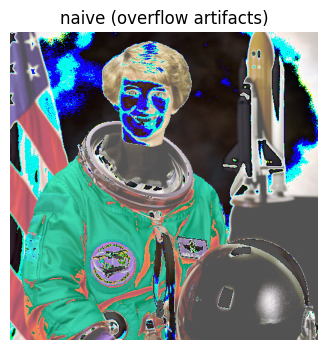

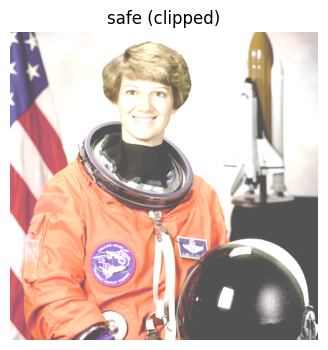

In [ ]:
# Naive brightening (GIVEN): uint8 + uint8 wraps past 255
naive = img + np.uint8(DELTA)

# --- Q3a: brighten SAFELY (float32 -> +DELTA -> clip 0..255 -> uint8) ---
safe = np.clip(img.astype(np.float32) + DELTA, 0, 255).astype(np.uint8)          # TODO

# --- Q3b: how many pixels overflowed? (where naive != safe) ---
num_wrapped = np.sum(naive != safe)   # TODO: count them

print("DELTA:", DELTA, "| pixels that overflowed:", num_wrapped)
show(naive, "naive (overflow artifacts)")
show(safe,  "safe (clipped)")

In [ ]:
first_overflow_coord = np.argwhere(naive != safe)[0]

# Extract coordinates for readability
of_y, of_x, of_ch = first_overflow_coord

original_value = img[of_y, of_x, of_ch]
naive_value = naive[of_y, of_x, of_ch]
safe_value = safe[of_y, of_x, of_ch]

print(f"Coordinate (Y, X, Channel): ({of_y}, {of_x}, {of_ch})")
print(f"Original value: {original_value}")
print(f"{DELTA=}")
print(f"Naive value: {naive_value}")
print(f"Safe value: {safe_value}")

Coordinate (Y, X, Channel): (0, 85, 0)
Original value: 174
DELTA=82
Naive value: 0
Safe value: 255


**Written:** Pick one pixel that overflowed. State its original value, its naive value, and its safe value, and explain **why** the naive result is wrong.

>>

Coordinate (Y, X, Channel): (0, 85, 0)

Original value: 174

DELTA=82

Naive value: 0

Safe value: 255

Here Original value + DELTA = 174 + 82 = 256 which exceeds the brightest value 255 but in the naive image it is shown as 0. That's why the naive result is wrong.

## Q4 — ROI & channel edit (20 pts)
Work with your ROI `img[RY1:RY2, RX1:RX2]`. Zero out channel `ZERO_CH` **inside the ROI only**, then paste it back into a copy of the full image.

**Predict:** in BGR, channel `ZERO_CH` is which colour, and what will visibly change inside the ROI?

> `ZERO_CH` is the BLUE color in the BGR format. If we make the channel value as 0 then GREEN and RED will mix up and create YELLOWish color.

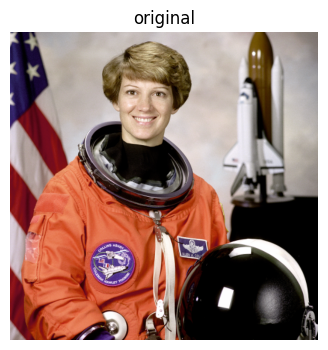

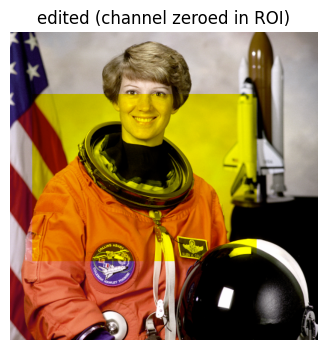

Q4 self-check: True


In [ ]:
# --- Q4: extract ROI, zero one channel, paste back ---
roi = img[RY1:RY2, RX1:RX2].copy()      # TODO: slice the ROI as an INDEPENDENT copy
roi[:, :, ZERO_CH] = 0                  # TODO: set channel ZERO_CH of roi to 0

edited = img.copy()
edited[RY1:RY2, RX1:RX2] = roi          # TODO: paste roi back into edited at the ROI location

show(img,    "original")
show(edited, "edited (channel zeroed in ROI)")
print("Q4 self-check:",
      edited.shape == img.shape and bool((edited[RY1:RY2, RX1:RX2, ZERO_CH] == 0).all()))

**Written (2–3 sentences):** Why did we use `.copy()` for `roi`? What would happen to `img` if we had sliced without copying and then modified `roi`?

> If we did not use `copy` from the **img** then making any changed to the sliced **roi** would have corupted the original image.

## Q5 — Annotation (20 pts)
On a copy of the image: draw a green rectangle around your ROI, a filled red circle at the ROI **centroid**, and a text label above the box. **Compute** the centroid from your ROI coordinates — do not hardcode it.

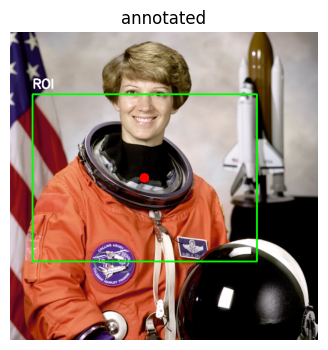

centroid: (223, 242)


In [ ]:
out = img.copy()
# TODO: draw a green rectangle from (RX1,RY1) to (RX2,RY2), thickness 2
cv2.rectangle(out, (RX1, RY1), (RX2, RY2), (0, 255, 0), 2)

cx, cy = (RX1+RX2) // 2, (RY1+RY2) // 2     # TODO: compute the ROI centroid

# TODO: draw a filled red circle at (cx, cy), radius 8
cv2.circle(out, (cx, cy), 8, (0, 0, 255), -1)
# TODO: put the text "ROI" just above the top-left corner of the box
cv2.putText(out, "ROI", (RX1, RY1 - 10), cv2.FONT_HERSHEY_SIMPLEX, 0.7, (255, 255, 255), 2)

show(out, "annotated")
print("centroid:", (cx, cy))

## Q6 — Debug & reflect (15 pts)
The function below should return the average pixel value of the box with top-left `(x1, y1)` and bottom-right `(x2, y2)`. It runs without error but returns the **wrong** region. Find the single bug, fix it, and explain it.

In [ ]:
def region_mean_buggy(image, x1, y1, x2, y2):
    region = image[x1:x2, y1:y2]     # <-- exactly one bug is on this line
    return region.mean()

# --- Q6: write the corrected function ---
def region_mean_fixed(image, x1, y1, x2, y2):
    region = image[y1:y2, x1:x2]    # TODO: fix the slicing
    return region.mean()

print("buggy:", round(region_mean_buggy(img, RX1, RY1, RX2, RY2), 3))
print("fixed:", round(region_mean_fixed(img, RX1, RY1, RX2, RY2), 3))

buggy: 127.822
fixed: 127.539


**Written:** What was the bug, and why does it return a wrong answer instead of raising an error? (Hint: what does NumPy do when a *slice* runs past the array edge, and how does `(x, y)` differ from `[row, col]`?)

> The bug was in the slicing order for the `region_mean_buggy` function. It used `image[x1:x2, y1:y2]` instead of the standard NumPy array indexing `image[y1:y2, x1:x2]`. In image processing, `x` typically refers to the column index (width) and `y` refers to the row index (height). However, NumPy arrays are indexed as `[row, column]` or `[height, width]`.
> It returned a wrong answer instead of an error because NumPy's slicing behavior is flexible. If a slice goes out of bounds, NumPy does not raise an error; instead, it returns an empty array or a smaller array containing only the valid indices. In this case, `x1:x2` and `y1:y2` might still define a valid, albeit incorrect, rectangular region, leading to a calculation on the wrong set of pixels.

**Reflection (3–4 sentences):** Describe one thing that surprised you while doing this assignment, referring to your specific image or numbers.

> I was surprised by how significant the difference between 'naive' and 'safe' brightening was for my image. With a DELTA of `82` for my astronaut image, a whopping `268624` pixels overflowed! This vividly demonstrated the importance of handling data types and potential overflows, especially in image processing where values are often constrained to 0-255. Without safe clipping, a substantial portion of the image would have incorrect color values, leading to noticeable visual artifacts. It made me realize that even seemingly simple operations like addition require careful consideration of numerical limits.

## Submission Summary
Run this last and keep the printed output in your submitted file.

In [ ]:
# === SUBMISSION SUMMARY — run last, keep the output ===
print("Roll number :", ROLL_NUMBER)
print("Seed        :", seed)
print("Image       :", img_name)
print("Q1 H,W,ch   :", img_H, img_W, num_channels, "| aspect", aspect_ratio)
print("Q2 BGR      :", (int(b), int(g), int(r)), "| dominant", dominant)
print("Q3 wrapped  :", num_wrapped, "| delta", DELTA)
print("Q4 zero_ch  :", ZERO_CH, "| ROI", (RX1, RY1, RX2, RY2))
print("Q5 centroid :", (cx, cy))
print("Q6 fixed    :", round(region_mean_fixed(img, RX1, RY1, RX2, RY2), 3))

Roll number : 901503252
Seed        : 279384723
Image       : astronaut
Q1 H,W,ch   : 512 512 3 | aspect 1.0
Q2 BGR      : (205, 201, 202) | dominant 205
Q3 wrapped  : 268624 | delta 82
Q4 zero_ch  : 0 | ROI (37, 103, 410, 381)
Q5 centroid : (223, 242)
Q6 fixed    : 127.539
